# Go MPC (Python Wrapper)

This notebook runs the Go implementation and then plots outputs from CSV files.


In [3]:
# %%
%load_ext autoreload
%autoreload 2
import os
import subprocess
import shutil
from pathlib import Path
import json
import numpy as np
from scipy.signal import cont2discrete


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Offline Phase (`GoVempc/cmd/ckks_offline/main.go`)
Implements Algorithm 1


In [ ]:
# Set configuration

def find_root(start: Path) -> Path:
    for p in [start] + list(start.parents):
        if (p / "go.mod").exists() and (p / "cmd" / "ckks_offline").exists():
            return p
        if (p / "GoVempc" / "go.mod").exists():
            return p / "GoVempc"
    return start

ROOT = find_root(Path.cwd())
out = ROOT / "output"
out.mkdir(parents=True, exist_ok=True)

cfg = {
    "m": 0.2,
    "l": 0.5,
    "g": 9.81,
    "dt": 0.05,
    "N": 10, # MPC horizon
    "QDiag": [50.0, 5.0],
    "RDiag": [0.1],
    "QfScale": 2.0,
    # Initial condition
    "x0": [0.3, 0.1],
    # Constraints
    "thetaMax": 0.5,
    "omegaMax": 0.8,
    "uMax": 1.0,
    # Variational mpc parameters
    "sigma0": 0.25,
    "lambda": 0.1,
    # Encryption paramters
    # "logN": 13,
    # "logQ": [30, 30, 30, 30],
    # "logP": [30],
    # "logDefaultScale": 30,
    # ======================
    # Parameter sets that satisfies 128-bit security
    "logN": 13,
    "logQ": [33, 30, 30, 30, 30, 30],
    "logP": [35],
    "logDefaultScale": 30,
    # =========================
    # "logN":            14,
    # "logQ":            [45, 34, 34, 34, 34, 34, 34, 34, 34, 34],
    # "logP":            []int{44, 43},
    # "logDefaultScale": 34,
    # =========================
    # "logN":            15,
    # "logQ":            [51, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40],
    # "logP":            [44, 43],
    # "logDefaultScale": 34,

    # Number of total samples
    "K": 240,
    "nWorkers": 4,
    # K_chunk = 60
    # "K": 60,
    # "nWorkers": 1,
    # Simulation timesteps
    "T": 40,
    "chebOrder": 3,
    "chebBound": 5.0,
    "chebEta": 500.0
}
(out / "ckks_config.json").write_text(json.dumps(cfg, indent=2))
print("Wrote", out / "ckks_config.json")


Wrote c:\Users\user\OneDrive\Writing\2026\4 CDC Var Enc MPPI\Variational-Encrypted-Model-Predictive-Control\GoVempc\output\ckks_config.json


In [5]:
# Run offline procedure Algorithm 1
import json
import os
import subprocess
from pathlib import Path

def find_root(start: Path) -> Path:
    for p in [start] + list(start.parents):
        if (p / "go.mod").exists() and (p / "cmd" / "ckks_offline").exists():
            return p
        if (p / "GoVempc" / "go.mod").exists():
            return p / "GoVempc"
    return start

ROOT = find_root(Path.cwd())
os.chdir(ROOT)

os.environ["GOMODCACHE"] = str(ROOT / ".gomodcache")
os.environ["GOCACHE"] = str(ROOT / ".gocache")
# If your environment blocks proxy, uncomment:
# os.environ["GOPROXY"] = "direct"

cfg = json.loads((ROOT / "output" / "ckks_config.json").read_text())
print(f"Offline config: K={cfg['K']}, nWorkers={cfg.get('nWorkers', 1)}, K_chunk={cfg['K'] // cfg.get('nWorkers', 1)}")
print("Running: go run ./cmd/ckks_offline")
res = subprocess.run(["go", "run", "./cmd/ckks_offline"], capture_output=True, text=True)
if res.stdout:
    print(res.stdout)
if res.returncode != 0 and res.stderr:
    print(res.stderr)


# With K=60, N_worker = 1 took
# Client offline time: 682.772 ms
# Cloud offline time: 26693.415 ms
# With K=240, N_worker = 4 took
# Client offline time: 669.994 ms
# Cloud offline time: 33836.844 ms
# Not exactly scalable but almost same

Offline config: K=240, nWorkers=4, K_chunk=60
Running: go run ./cmd/ckks_offline
A =
⎡1.0246254099832466  0.05040975363090225⎤
  ⎣0.9890393662383021   1.0246254099832466⎦
B =
⎡0.025102354722983437⎤
  ⎣  1.0081950726180449⎦
Slot width: 60, slots needed per worker: 3600
CKKS slots: 4096
L_U dims: 10x10
Gamma dims: 60x10
CKKS slots: 4096, K: 240, nWorkers: 4, K_chunk: 60, T: 40
Cache Enc(L_U * xi): T=40, workers=4, packed=60 samples per ct
Cache Enc(Gamma * xi): T=40, workers=4, packed=60 samples per ct
Client offline time: 1311.564 ms
Cloud offline time: 585785.761 ms



### Online Phase (`GoVempc/cmd/ckks_online/main.go`)
Implements Algorithm 2


In [6]:
# Run online procedure Algorithm 2
import json
import os
import subprocess
import sys
from pathlib import Path

def find_root(start: Path) -> Path:
    for p in [start] + list(start.parents):
        if (p / "go.mod").exists() and (p / "cmd" / "ckks_online").exists():
            return p
        if (p / "GoVempc" / "go.mod").exists():
            return p / "GoVempc"
    return start

ROOT = find_root(Path.cwd())
os.chdir(ROOT)

os.environ["GOMODCACHE"] = str(ROOT / ".gomodcache")
os.environ["GOCACHE"] = str(ROOT / ".gocache")

cfg = json.loads((ROOT / "output" / "ckks_config.json").read_text())
print(f"Online config: K={cfg['K']}, nWorkers={cfg.get('nWorkers', 1)}, K_chunk={cfg['K'] // cfg.get('nWorkers', 1)}")

proc = subprocess.Popen(
    ["go", "run", "./cmd/ckks_online"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)
if proc.stdout is not None:
    for line in proc.stdout:
        print(line, end="")
ret = proc.wait()
if ret != 0:
    print(f"Process exited with code {ret}")



Online config: K=240, nWorkers=4, K_chunk=60
step 0 control_iter_ms 75.823
step 1 control_iter_ms 77.831
step 2 control_iter_ms 74.746
step 3 control_iter_ms 70.981
step 4 control_iter_ms 75.567
step 5 control_iter_ms 68.248
step 6 control_iter_ms 75.344
step 7 control_iter_ms 64.695
step 8 control_iter_ms 66.740
step 9 control_iter_ms 74.001
step 10 control_iter_ms 68.192
step 11 control_iter_ms 72.650
step 12 control_iter_ms 80.220
step 13 control_iter_ms 87.235
step 14 control_iter_ms 77.759
step 15 control_iter_ms 80.750
step 16 control_iter_ms 76.996
step 17 control_iter_ms 70.352
step 18 control_iter_ms 68.989
step 19 control_iter_ms 63.717
step 20 control_iter_ms 66.929
step 21 control_iter_ms 70.373
step 22 control_iter_ms 78.388
step 23 control_iter_ms 85.369
step 24 control_iter_ms 86.524
step 25 control_iter_ms 98.674
step 26 control_iter_ms 90.019
step 27 control_iter_ms 93.176
step 28 control_iter_ms 107.876
step 29 control_iter_ms 105.611
step 30 control_iter_ms 86.739
st

In [7]:
# Unencrypted variational MPC
import os
import json
import subprocess
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt

# Locate GoVempc root

def find_root(start: Path) -> Path:
    for p in [start] + list(start.parents):
        if (p / "go.mod").exists() and (p / "cmd" / "test").exists():
            return p
        if (p / "GoVempc" / "go.mod").exists():
            return p / "GoVempc"
    return start

ROOT = find_root(Path.cwd())
os.chdir(ROOT)

os.environ["GOMODCACHE"] = str(ROOT / ".gomodcache")
os.environ["GOCACHE"] = str(ROOT / ".gocache")

cfg_path = ROOT / "output" / "ckks_config.json"
if not cfg_path.exists():
    raise FileNotFoundError("Missing output/ckks_config.json; run the config cell above first.")

print("Running: go run ./cmd/test")
res = subprocess.run(["go", "run", "./cmd/test"], capture_output=True, text=True)
if res.stdout:
    print(res.stdout)
if res.returncode != 0 and res.stderr:
    print(res.stderr)

cfg = json.loads(cfg_path.read_text())
dt = float(cfg["dt"])
theta_max = float(cfg["thetaMax"])
omega_max = float(cfg["omegaMax"])
u_max = float(cfg["uMax"])

OUT = ROOT / "output"
xs_var = np.loadtxt(OUT / "xs_variational.csv", delimiter=",", ndmin=2)
us_var = np.loadtxt(OUT / "us_variational.csv", delimiter=",", ndmin=2)



Running: go run ./cmd/test
Standard MPC
  runtime: 8ms
  cost:    34.237244
  viol:    (x=0.000000, u=0.000123)
Variational MPC
  runtime: 10ms
  cost:    34.418244
  viol:    (x=0.000000, u=0.000000)
  w_sum mean: 233.550000
  accept mean: 233.550000

Saved CSV outputs to output
Saved plots to output\plots



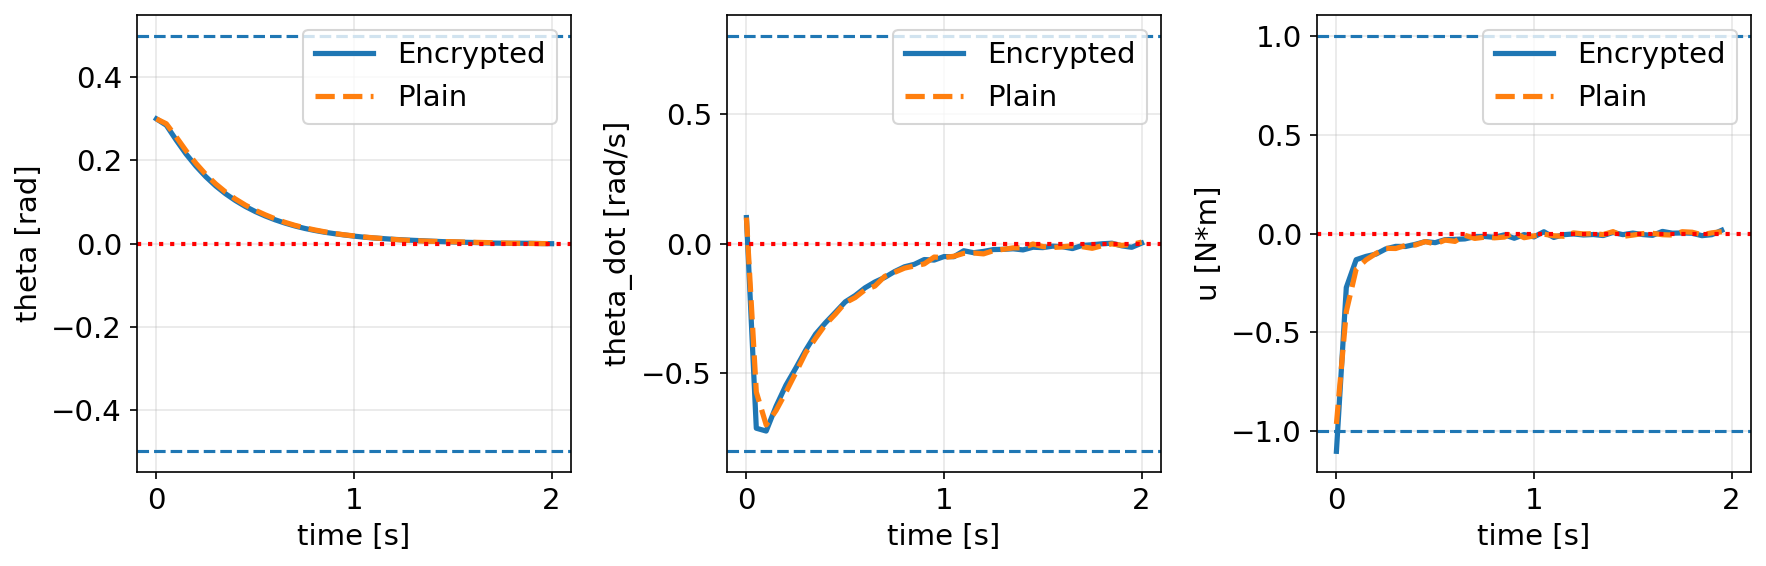

Saved overlay plot to C:\Users\user\OneDrive\Writing\2026\4 CDC Var Enc MPPI\Variational-Encrypted-Model-Predictive-Control\GoVempc\output\overlay_plot.png


In [8]:
# Overlay encrypted vs plain variational MPC results
import json
import numpy as np
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt
from IPython.display import Image, display
from pathlib import Path
import tikzplotlib

OUT = Path("output")
cfg = json.loads((OUT / "ckks_config.json").read_text())

dt = float(cfg["dt"])
theta_max = float(cfg["thetaMax"])
omega_max = float(cfg["omegaMax"])
u_max = float(cfg["uMax"])

xs_ckks = np.loadtxt(OUT / "xs_ckks.csv", delimiter=",", ndmin=2)
us_ckks = np.loadtxt(OUT / "us_ckks.csv", delimiter=",", ndmin=2)
xs_plain = np.loadtxt(OUT / "xs_variational.csv", delimiter=",", ndmin=2)
us_plain = np.loadtxt(OUT / "us_variational.csv", delimiter=",", ndmin=2)

t_ckks = np.arange(xs_ckks.shape[0]) * dt
t_plain = np.arange(xs_plain.shape[0]) * dt
tu_ckks = np.arange(us_ckks.shape[0]) * dt
tu_plain = np.arange(us_plain.shape[0]) * dt

plt.rcParams.update({"font.size": 14})
fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharex=True)
ax = ax.ravel()

def add_bounds(a, bound):
    a.axhline(0.0, color="red", linestyle=":", linewidth=2.0)
    a.axhline(+bound, linestyle="--")
    a.axhline(-bound, linestyle="--")

# theta
ax[0].plot(t_ckks, xs_ckks[:, 0], label="Encrypted", linewidth=2.5)
ax[0].plot(t_plain, xs_plain[:, 0], label="Plain", linewidth=2.5, linestyle="--")
add_bounds(ax[0], theta_max)
ax[0].set_ylabel("theta [rad]")
ax[0].grid(True, alpha=0.3)
ax[0].legend()

# theta_dot
ax[1].plot(t_ckks, xs_ckks[:, 1], label="Encrypted", linewidth=2.5)
ax[1].plot(t_plain, xs_plain[:, 1], label="Plain", linewidth=2.5, linestyle="--")
add_bounds(ax[1], omega_max)
ax[1].set_ylabel("theta_dot [rad/s]")
ax[1].grid(True, alpha=0.3)
ax[1].legend()

# u
ax[2].plot(tu_ckks, us_ckks[:, 0], label="Encrypted", linewidth=2.5)
ax[2].plot(tu_plain, us_plain[:, 0], label="Plain", linewidth=2.5, linestyle="--")
add_bounds(ax[2], u_max)
ax[2].set_ylabel("u [N*m]")
ax[2].grid(True, alpha=0.3)
ax[2].legend()

for a in ax:
    a.set_xlabel("time [s]")

plt.tight_layout()
plot_path = OUT / "overlay_plot.png"
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
tikzplotlib.save("traj.tex")
plt.close(fig)
display(Image(filename=str(plot_path)))
print(f"Saved overlay plot to {plot_path.resolve()}")
